In [1]:
# install models
#%pip install requests
#%pip install mplfinance

In [2]:
import os
import csv
import sys
import time
import json
import typing as t  
import requests
import pandas as pd
import numpy as np
from typing import Dict, Iterable, Optional
from pathlib import Path
import mplfinance as mpf
import matplotlib.pyplot as plt

from datetime import date, datetime, timezone
from dprojectstools.secrets import SecretsManager

# **************
# **  Secrets **
# **************
SECRETS_DB = "xtrader"
API_KEY = SecretsManager(SECRETS_DB).get("polygon.key")

# **************
# **  Config  **
# **************

OUTPUT_PATH = "../work/data"
CACHE_PATH = "../work/cache"
DOWNLOAD_PATH = "../work/download"

DATETIME_COL = "datetime_utc"
TICKERS =  [ "AAPL", "MSFT", "NVDA", "IBM", "GOOG" ]
YEARS = 4
FROM_YEAR = 2021
MULTIPLIER = 1
TIMESPAN = "hour"

# ETF_WEIGTHS = "equals"
ETF_WEIGTHS = "marketcap"



In [3]:
# clear data directory
for filename in os.listdir(OUTPUT_PATH):
    file_path = os.path.join(OUTPUT_PATH, filename)
    if os.path.isfile(file_path):
        os.remove(file_path)



In [4]:
def get_candles(ticker: str, multiplier: str, timespan: str, date_from:str, date_to: str):
    cache_path = CACHE_PATH + "/" + ticker + "_" + str(multiplier) + timespan + "_" + str(date_from) + "_" + str(date_to) + ".csv"
    # check
    if os.path.isfile(cache_path):
        df = pd.read_csv(cache_path, parse_dates=[DATETIME_COL])
        return df
    # download
    results: list[dict] = []
    base = f"https://api.polygon.io/v2/aggs/ticker/{ticker}/range/{multiplier}/{timespan}/{date_from}/{date_to}"
    params = {
        "adjusted": str(True).lower(),
        "sort": "asc",
        "limit": str(50000),
        "apiKey": API_KEY,
    }
    def get(url: str, params: dict | None = None) -> dict:
        r = requests.get(url, params=params, timeout=60)
        # Raise for HTTP errors with clear message
        try:
            r.raise_for_status()
        except requests.HTTPError as e:
            raise SystemExit(f"HTTP error {r.status_code}: {r.text}") from e
        try:
            return r.json()
        except json.JSONDecodeError as e:
            raise SystemExit(f"Non-JSON response: {r.text[:500]}") from e
        
    # first request
    data = get(base, params)
    if data.get("status") not in {"OK", "DELAYED"}:
        # DELAYED can occur when data is still being processed; often still has results
        msg = data.get("error") or data.get("message") or str(data)
        print(f"Warning: status={data.get('status')}, message={msg}", file=sys.stderr)

    if "results" in data and isinstance(data["results"], list):
        results.extend(data["results"])

    # Follow pagination via next_url
    next_url = data.get("next_url")
    # Polygon's next_url may omit the apiKey; add it if missing
    while next_url:
        # Respect polite pacing to avoid rate limits (tweak as needed)
        time.sleep(0.12)
        sep = "&" if "?" in next_url else "?"
        url = next_url + ("" if "apiKey=" in next_url else f"{sep}apiKey={API_KEY}")
        data = get(url, None)
        if "results" in data and isinstance(data["results"], list):
            results.extend(data["results"])
        next_url = data.get("next_url")
    # write to cache
    #fieldnames = ["datetime_utc","open","high","low","close","volume","vwap","trades",]
    fieldnames = ["datetime_utc","open","high","low","close","volume"]
    with open(cache_path, "w", newline="", encoding="utf-8") as f:
        w = csv.writer(f)
        w.writerow(fieldnames)
        for bar in results:
            t_ms = int(bar["t"])
            dt = datetime.fromtimestamp(t_ms / 1000, tz=timezone.utc).strftime("%Y-%m-%d %H:%M:%S")
            if timespan == "day":
                dt = dt[0:10] + " 00:00:00"
            o = bar.get("o")
            h = bar.get("h")
            l = bar.get("l")
            c = bar.get("c")
            v = bar.get("v")
            vw = bar.get("vw", "")
            n = bar.get("n")
            #w.writerow([dt, o, h, l, c, v, vw, n])
            w.writerow([dt, o, h, l, c, v])
    # read from cache
    df = pd.read_csv(cache_path, parse_dates=[DATETIME_COL])
    # return
    return df

# download data
for ticker in TICKERS:
    print(f"Descargando datos: {ticker}...")
    df = get_candles(ticker, MULTIPLIER, TIMESPAN, date(FROM_YEAR, 1, 1), date(FROM_YEAR + YEARS, 1, 1))
    df.to_csv(OUTPUT_PATH + f"/{ticker}.csv", index=False)

    


Descargando datos: AAPL...
Descargando datos: MSFT...
Descargando datos: NVDA...
Descargando datos: IBM...
Descargando datos: GOOG...


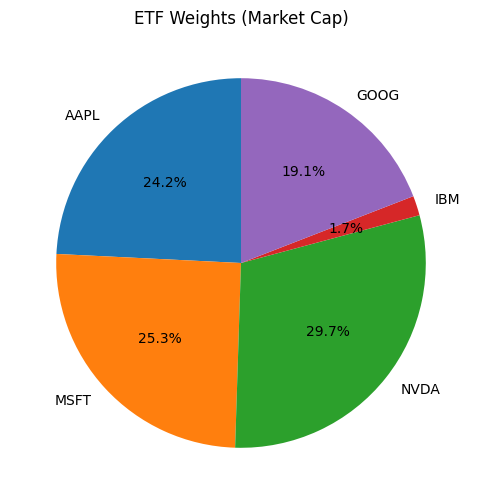

In [5]:
# get weights
weights = {}

if ETF_WEIGTHS == "marketcap":
    #marketcap weights
    market_caps = {}
    for ticker in TICKERS:
        url = f"https://api.polygon.io/v3/reference/tickers/{ticker}?apiKey={API_KEY}"
        data = requests.get(url).json()
        market_caps[ticker] = data["results"].get("market_cap", 0)

    total = sum(market_caps.values())
    weights = {ticker: market_cap / total for ticker, market_cap in market_caps.items()}
elif ETF_WEIGTHS == "equals":
    # equal weights
    for ticker in TICKERS:
        weights[ticker] = 1 /  len(TICKERS)

with open(OUTPUT_PATH + "/etf_weights.json", "w", encoding="utf-8") as file:
    json.dump(weights, file, ensure_ascii=False, indent=4)

# Explicación: se debe explicar que obtenemos el MarketCap en fecha 01/09/2025, ya que no se dispone del marketcap real en la fecha de inicio (2021)
# Consideramos esta "aproximación" válida, ya que los pesos relativos de cada STOCK no distorsionaran suficiente los resultados como para invalidarlos

# plot
plt.figure(figsize=(6,6))
plt.pie(weights.values(), labels=weights.keys(), autopct="%.1f%%", startangle=90)
plt.title("ETF Weights (Market Cap)")
plt.show()


In [6]:
# alineación de los datos (nos aseguramos que la serie temporal sea consistente, sin valores faltantes)
# para noches y fines de semana y valores faltantes, crea un registro sintéticos con:
# - open = close = high = low = last known Close
# - volume = 0
# - is_synthetic = True
dfs = {}
for ticker in TICKERS:
    print(f"Alineando datos: {ticker}...")
    
    input_path = OUTPUT_PATH + f"/{ticker}.csv"
    output_path = OUTPUT_PATH + f"/{ticker}1.csv"
    
    df = pd.read_csv(input_path, parse_dates=[DATETIME_COL])
    df = df.sort_values(DATETIME_COL)
    df = df.set_index(DATETIME_COL)

    # create full hourly range (from first to last timestamp)
    freq = str(MULTIPLIER)
    if TIMESPAN == "minute":
        freq += "min"
    elif TIMESPAN == "hour":
        freq += "h"
    elif TIMESPAN == "day":
        freq += "d"

    full_range = pd.date_range(start=df.index.min(), end=df.index.max(), freq=freq)

    # Keep original index to mark synthetic rows later
    orig_idx = df.index

    # reindex to include all hours (nights + weekends included)
    df = df.reindex(full_range)

    # mark which are synthetic (missing in original)
    df["is_synthetic"] = ~df.index.isin(orig_idx)

    # rename index back to column
    df.index.name = DATETIME_COL
    df.reset_index(inplace=True)

    # fill synthetic OHLC:
    # - open = close = high = low = last known Close
    # - volume = 0
    df["close"] = df["close"].ffill()
    df["open"]  = df["open"].fillna(df["close"])
    df["high"]  = df["high"].fillna(df["close"])
    df["low"]   = df["low"].fillna(df["close"])
    df["volume"] = df["volume"].fillna(0)

    # save
    df.to_csv(output_path, index=False)
    dfs[output_path] = df
    df.set_index(DATETIME_COL, inplace=True)

# obtiene el rango de fechas compartido por todos los datasets
start = max(df.index.min() for df in dfs.values())
end   = min(df.index.max() for df in dfs.values())
for filename in dfs.keys():
    df = dfs[filename]
    df = df.loc[df.index >= start]
    df = df.loc[df.index <= end]
    df.reset_index(inplace=True)
    df.to_csv(filename, index=False)



Alineando datos: AAPL...
Alineando datos: MSFT...
Alineando datos: NVDA...
Alineando datos: IBM...
Alineando datos: GOOG...


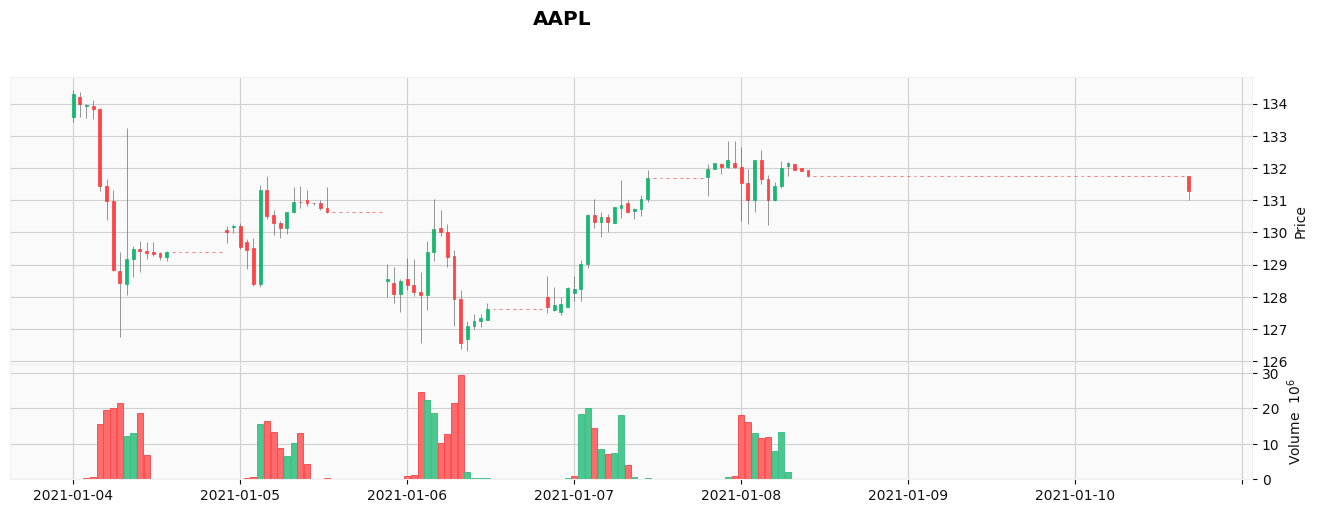

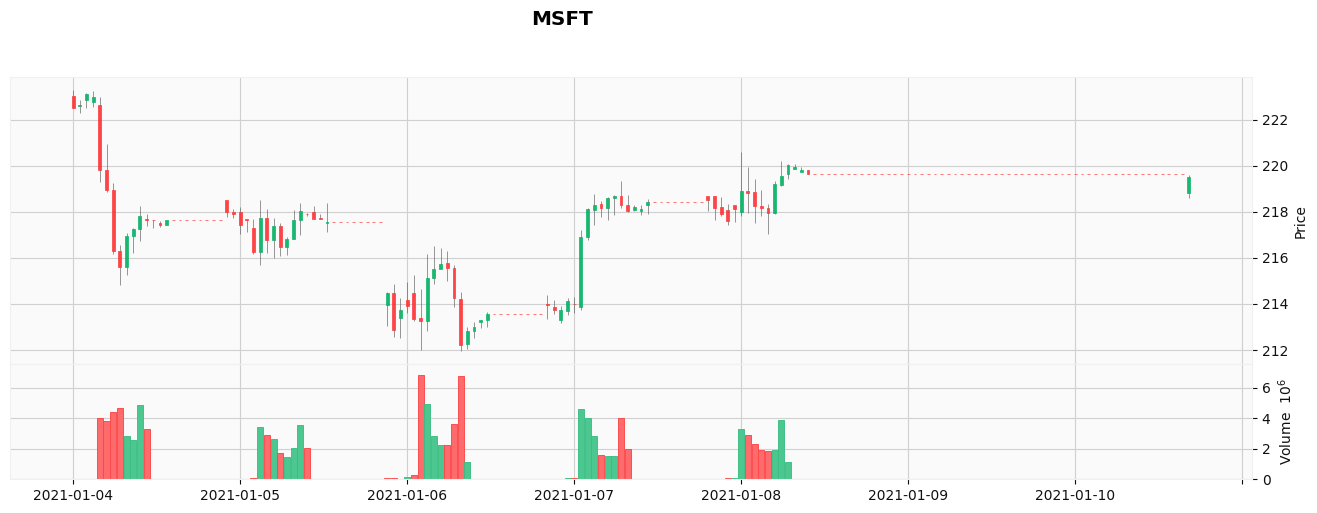

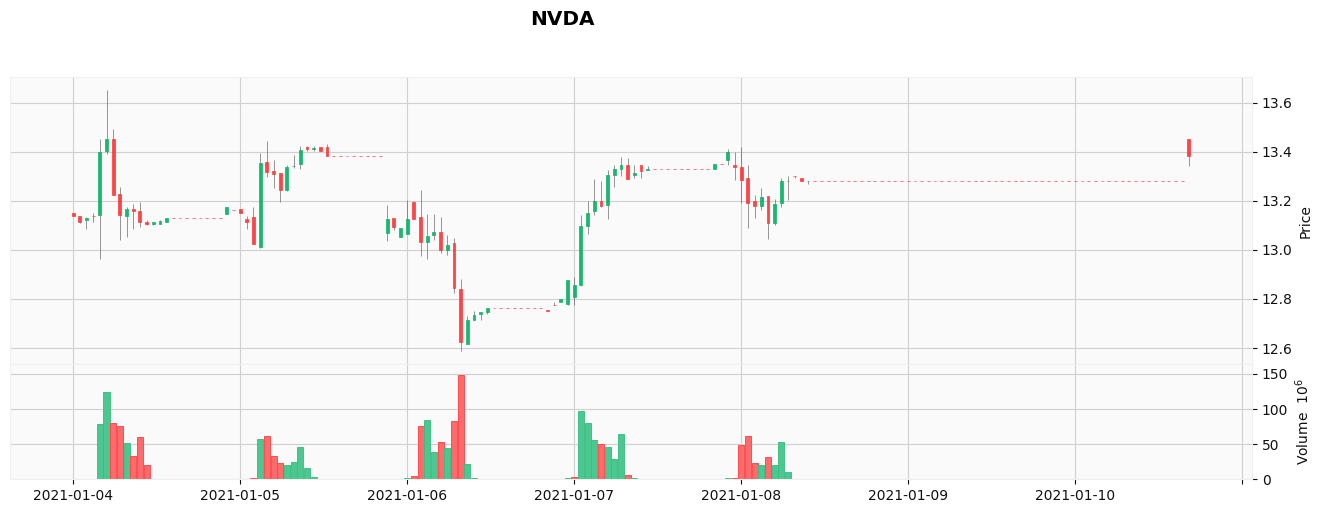

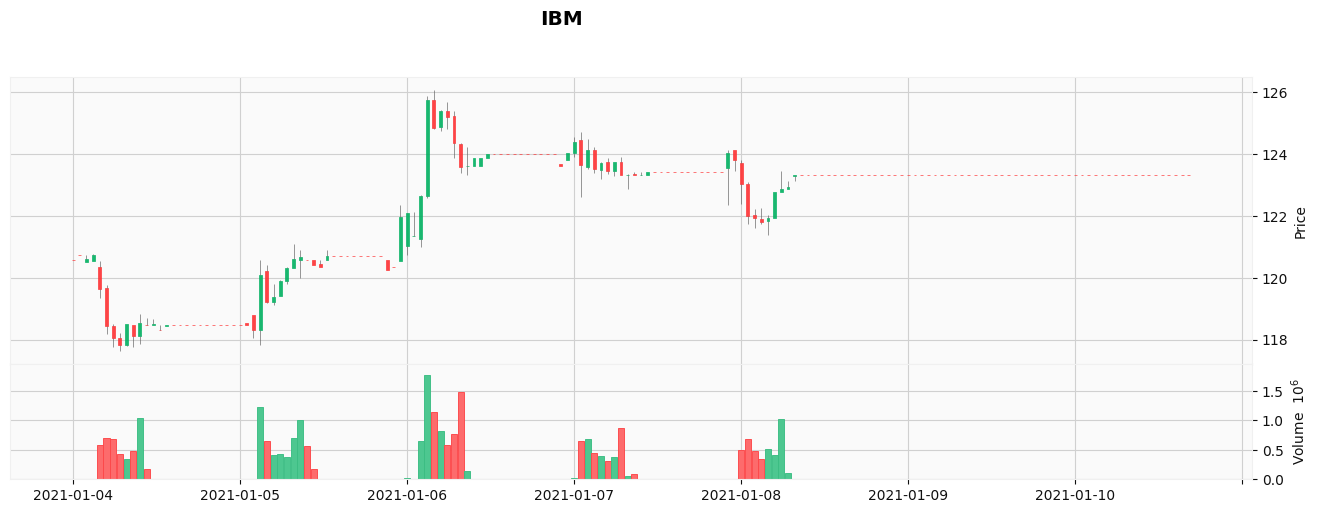

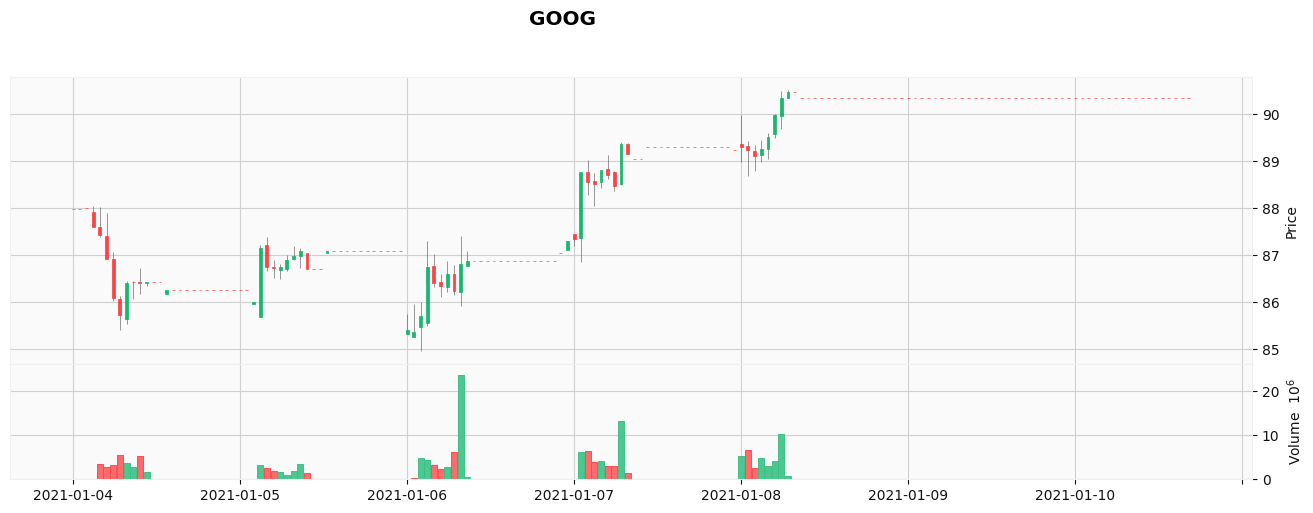

In [7]:
# muestra una parte de los datos como velas
for ticker in TICKERS:
    input_path = OUTPUT_PATH + f"/{ticker}1.csv"
    df = pd.read_csv(input_path, parse_dates=[DATETIME_COL])
    df = df.set_index(DATETIME_COL)
    #plot
    mpf.plot(df.head(24*7*1), type="candle", style="yahoo", volume=True, title=ticker, figratio=(3, 1), datetime_format="%Y-%m-%d", xrotation=0 )

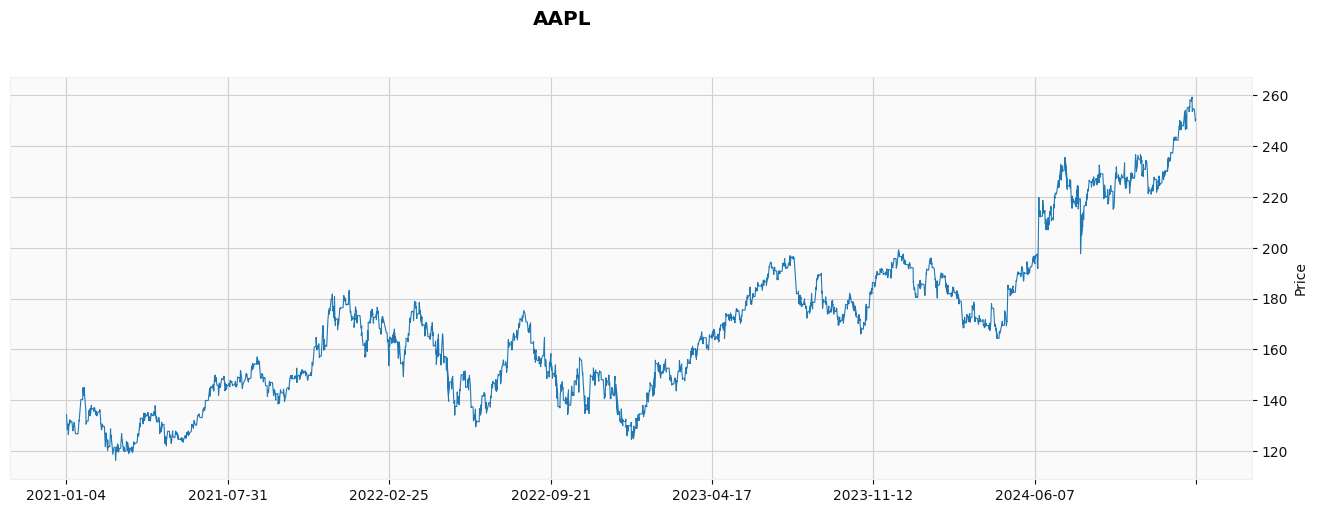

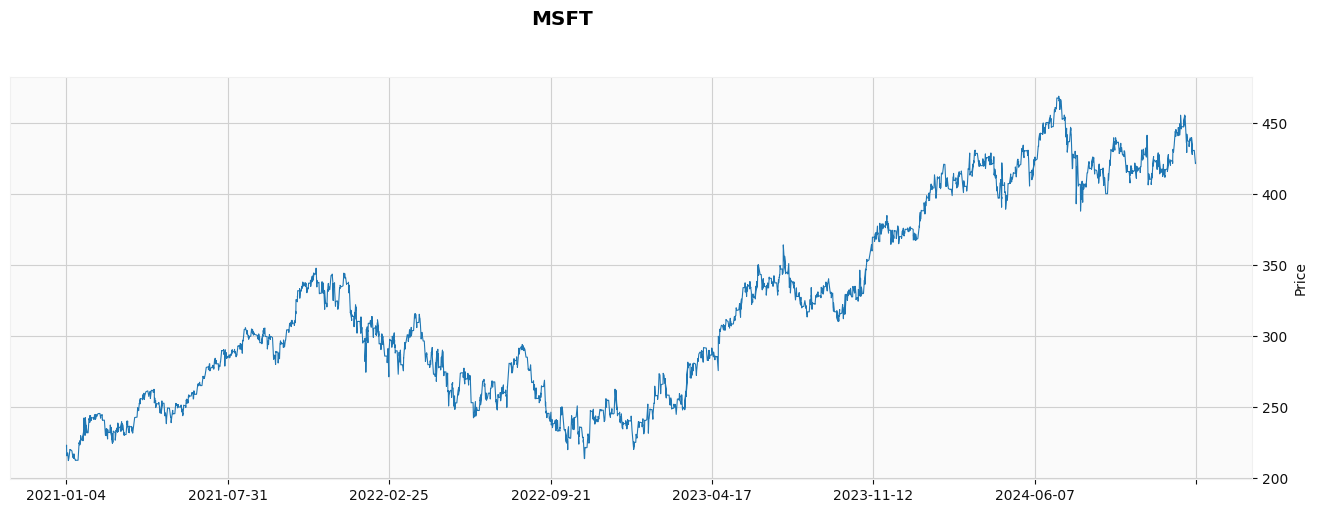

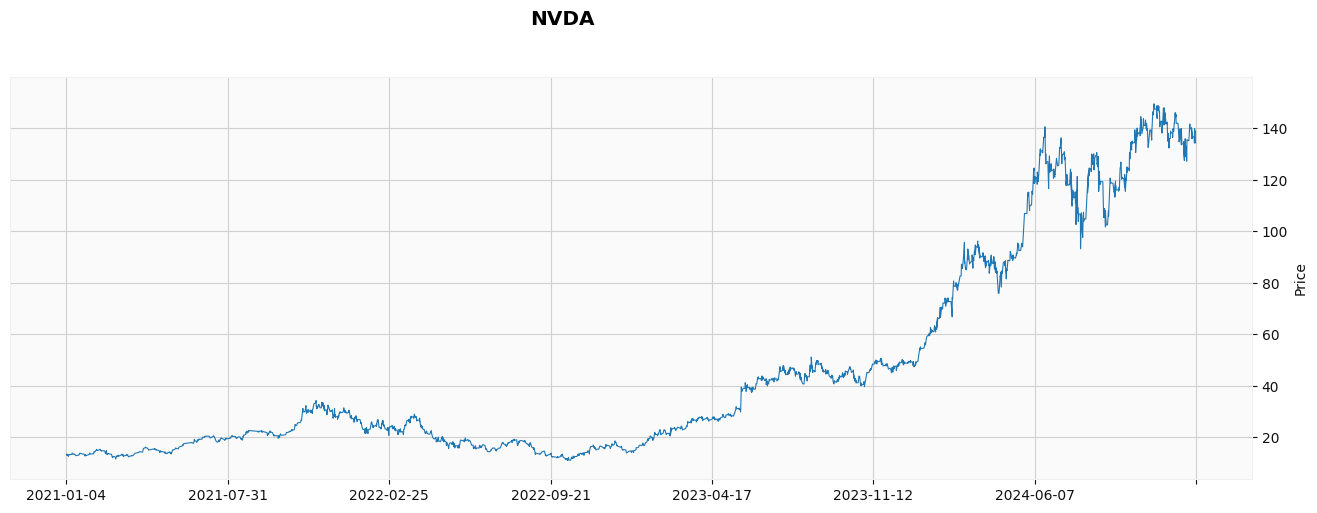

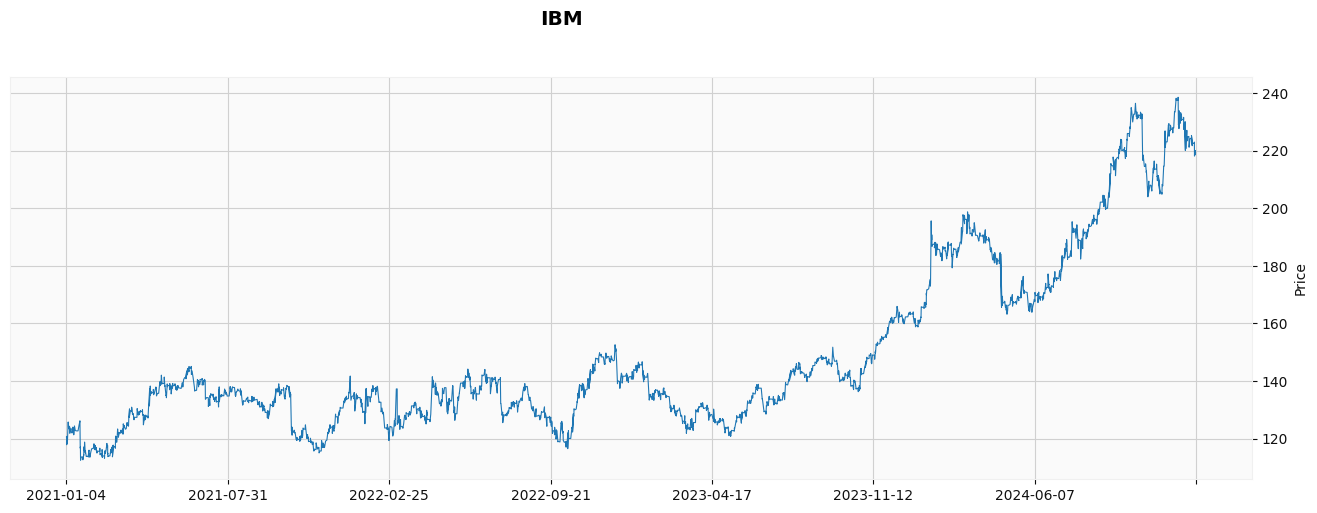

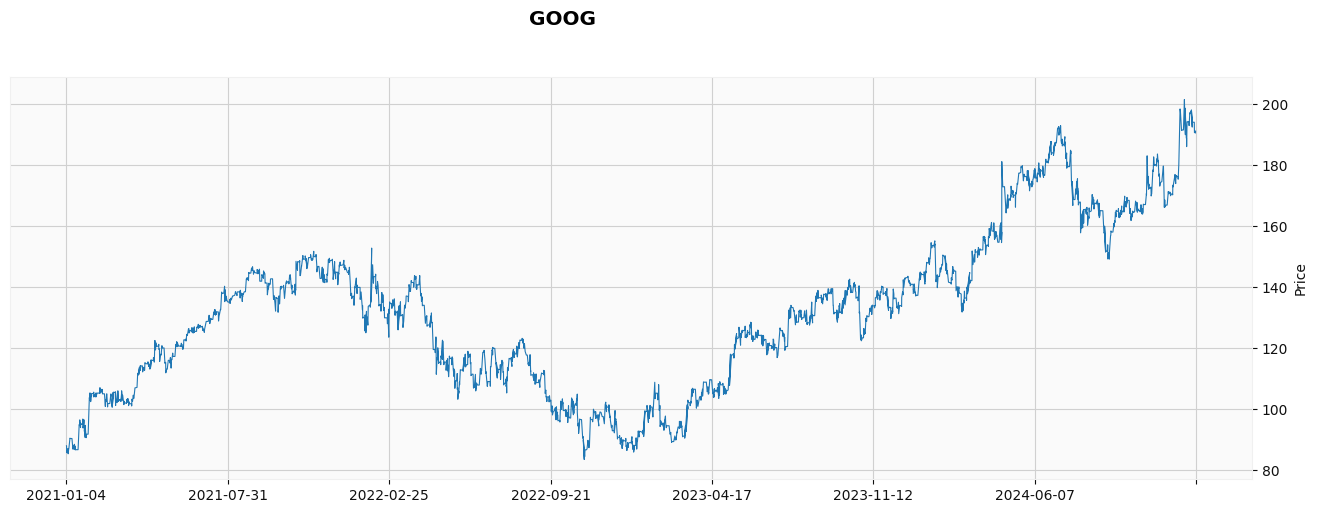

In [8]:
# muestra los datos
for ticker in TICKERS:
    input_path = OUTPUT_PATH + f"/{ticker}1.csv"
    df = pd.read_csv(input_path, parse_dates=[DATETIME_COL])
    df = df.set_index(DATETIME_COL)
    #plot
    mpf.plot(df, type="line", style="yahoo", volume=False, title=ticker, figratio=(3, 1), datetime_format="%Y-%m-%d", xrotation=0 )
    

Buscando Outliers: AAPL...
... 789/34981 outliers (2.26 %)


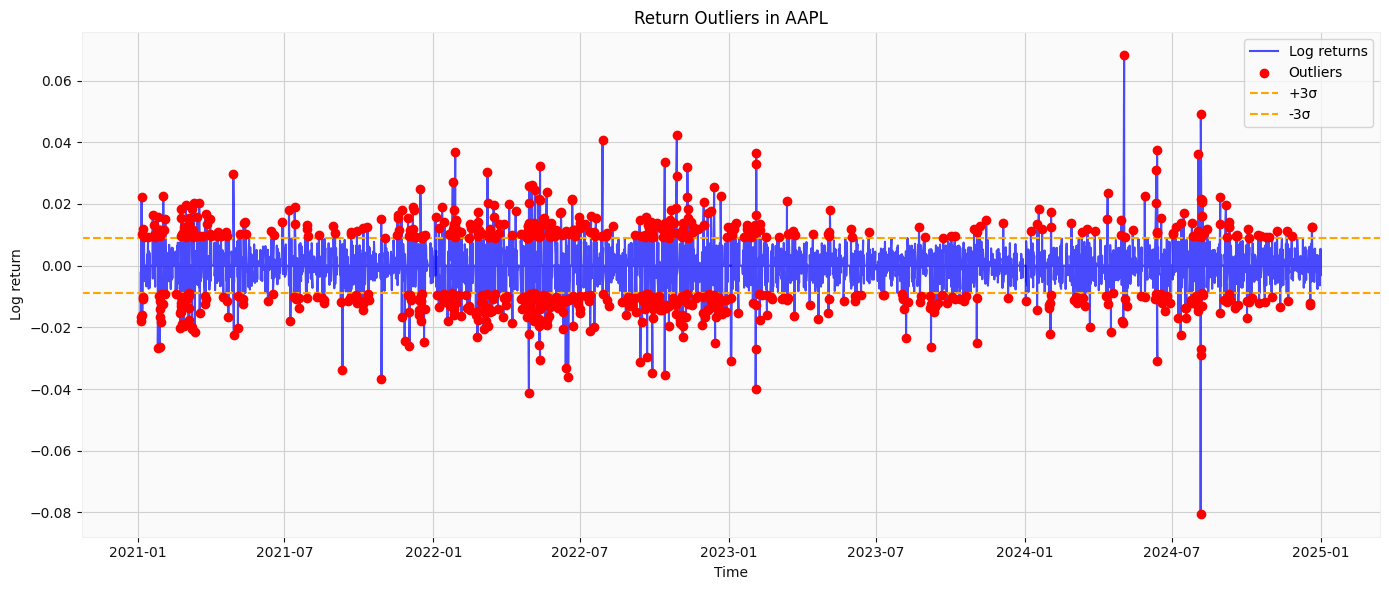

Buscando Outliers: MSFT...
... 767/34981 outliers (2.19 %)


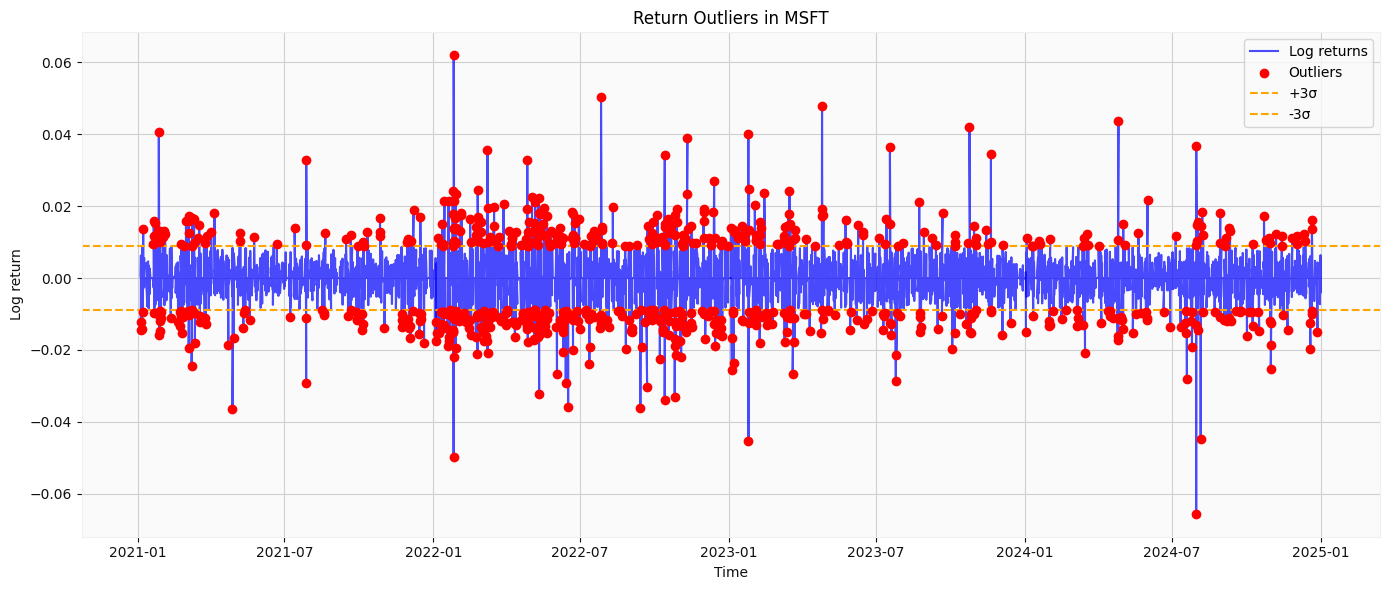

Buscando Outliers: NVDA...
... 851/34981 outliers (2.43 %)


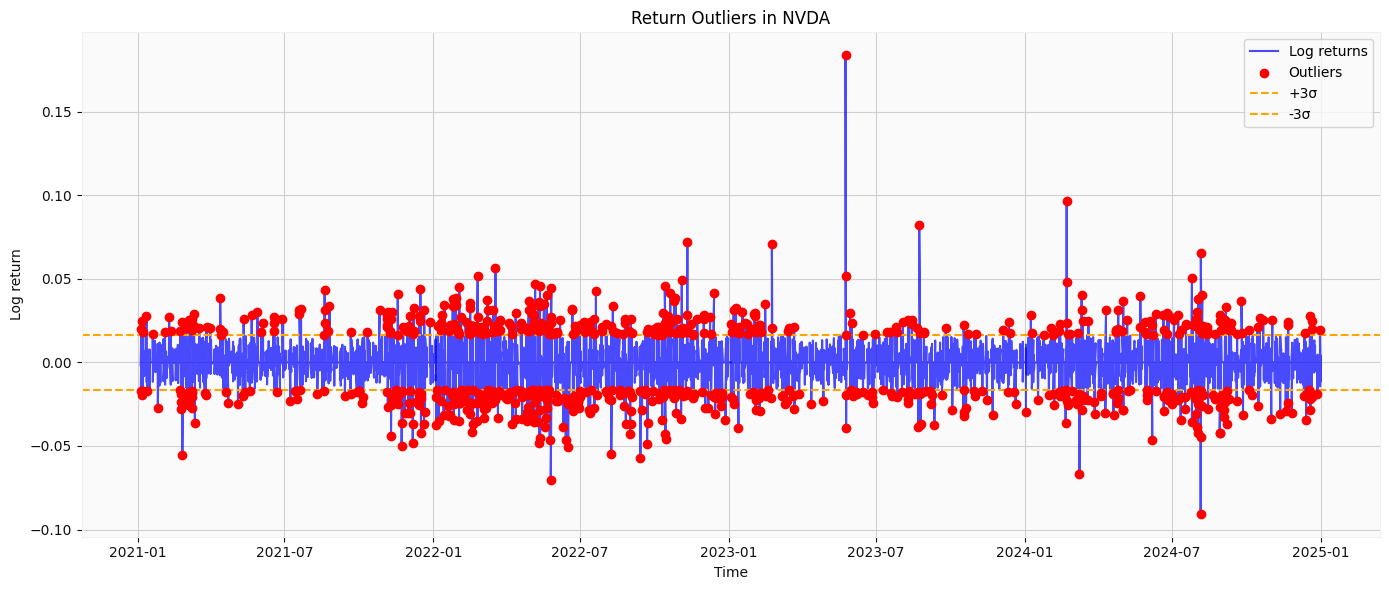

Buscando Outliers: IBM...
... 675/34981 outliers (1.93 %)


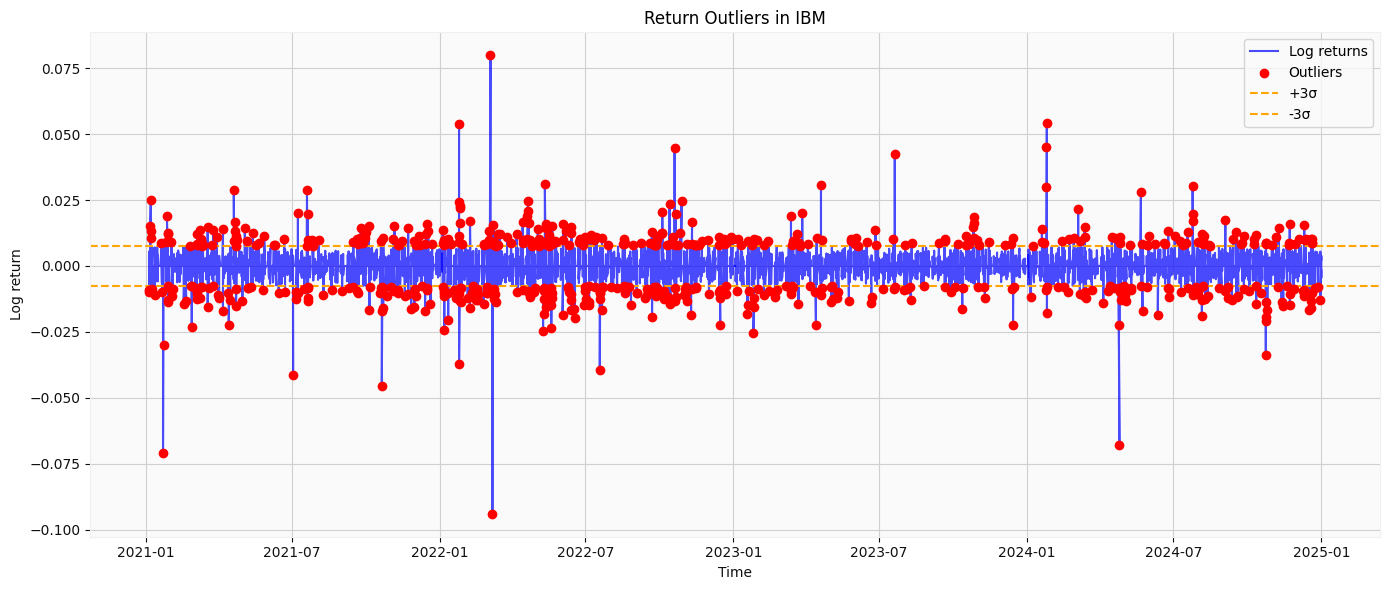

Buscando Outliers: GOOG...
... 763/34981 outliers (2.18 %)


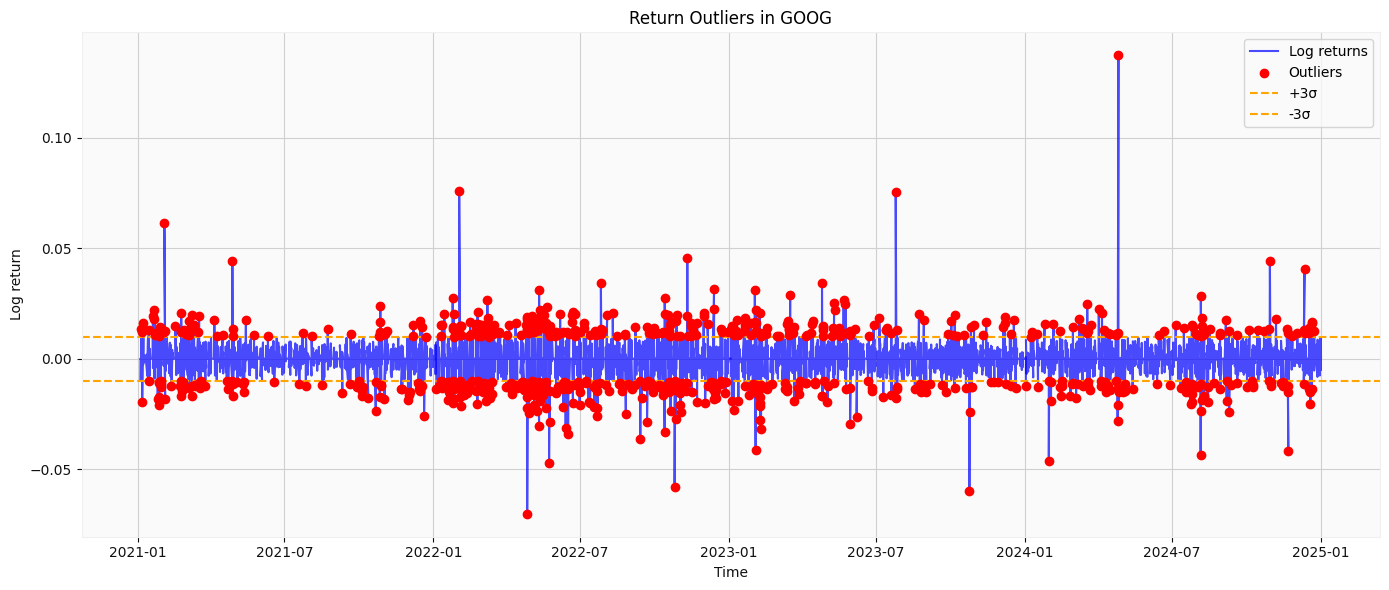

In [9]:
# busca outliers
process_outliers = False
for TICKER in TICKERS:
    print(f"Buscando Outliers: {TICKER}...")
    count = 0
    input_path = OUTPUT_PATH + f"/{TICKER}1.csv"
    output_path = OUTPUT_PATH + f"/{TICKER}2.csv"
    df = pd.read_csv(input_path, parse_dates=[DATETIME_COL])
    
    # compute log return
    df["log_return"] = np.log(df["close"] / df["close"].shift(1))

    # --- Rule 1: Return outliers ( rt​=ln(Ct−1​Ct​​) > 5σ) ---
    #  - Computes log-returns between closes.
    #  - Flags any candle where the return is more than 5 standard deviations away from the mean.
    #  - Purpose: catch extreme price jumps that are unlikely to be real.
    z_thresh = 3
    mean = df["log_return"].mean(skipna=True)
    std  = df["log_return"].std(skipna=True)
    threshold = z_thresh * std
    df["ret_outlier"] = (df["log_return"].sub(mean).abs() > threshold ) & (df["is_synthetic"] == False) 
    
    mask = df["ret_outlier"]
    count += mask.sum()
    if process_outliers:
        # ¿Que hacemos? -> marcamos como NaN y hacemos un forward fill
        df.loc[mask, ["open","high","low","close","volume"]] = np.nan
        df.loc[mask, ["volume"]] = 0
        df.loc[mask, ["is_synthetic"]] = True
        # forward fill
        df[["open","high","low","close"]] = df[["open","high","low","close"]].ffill()
        # Explanation: For spurious outlier candles, OHLC values were forward-filled, volume was set to zero. This ensured consistency and avoided introducing synthetic averages while maintaining a complete dataset without missing values.
    
    # --- Rule 2: OHLC consistency ---
    # - Checks that the open and close are between the high and low.
    # - If not → candle is invalid (e.g. close higher than high, which should never happen).
    df["bad_ohlc"] = ~((df["low"] <= df[["open","close"]].min(axis=1)) &
                       (df[["open","close"]].max(axis=1) <= df["high"]) &
                       (df["is_synthetic"] == False) )
    # ¿Que hacemos? -> casi seguro que son anomalias técnicas -> reemplazamos con NaN
    # ... TODO (pero no hay ningun caso de estos)

    # --- Rule 3: Excessive range ---
    # - Measures intrabar volatility relative to price.
    # - Flags if high–low > 50% of the price.
    # - Purpose: detect suspicious spikes within a single candle.
    df["range_ratio"] = (df["high"] - df["low"]) / df["close"]
    df["range_outlier"] = (df["range_ratio"] > 0.5)  & (df["is_synthetic"] == False)
    # >50% intrabar move
    # ¿Que hacemos? --> reemplazamos high por max(open,close), low por min(open,close)
    # Explanation: “Range outliers (bars where (high–low)/close > 50%) were considered erroneous and replaced with NaN to prevent artificial volatility.”
    # ... TODO (pero no hay ningun caso de estos)

    # --- Rule 4: Zero volume anomaly ---
    # - If volume is reported as zero but the price changed → suspicious.
    # - A valid bar should not change price if no trades happened.
    df["vol_anomaly"] = (df["volume"] == 0) & (df["close"].diff().abs() > 0) & (df["is_synthetic"] == False)
    # ¿Que hacemos? -> casi seguro que son anomalias técnicas -> reemplazamos con NaN
    # ... TODO (pero no hay ningun caso de estos)
 
    # Collect all
    # outliers = df[df[["ret_outlier","bad_ohlc","range_outlier","vol_anomaly"]].any(axis=1)]

    # log
    print(f"... {count}/{len(df)} outliers ({(count/len(df))*100:.2f} %)")

    # mostramos los outliers de cada dataframe
    plt.figure(figsize=(14,6))
    plt.plot(df[DATETIME_COL], df["log_return"], label="Log returns", color="blue", alpha=0.7)
    plt.scatter(df.loc[df["ret_outlier"], DATETIME_COL], df.loc[df["ret_outlier"], "log_return"], color="red", label="Outliers", zorder=5)
    plt.axhline(mean + z_thresh*std , color="orange", linestyle="--", label=f"+{z_thresh}σ")
    plt.axhline(mean - z_thresh*std , color="orange", linestyle="--", label=f"-{z_thresh}σ")
    plt.title(f"Return Outliers in {TICKER}")
    plt.xlabel("Time")
    plt.ylabel("Log return")
    plt.legend()
    plt.tight_layout()
    plt.show()

     

    # hacemos un clip de los retornos que estan fuera del rango
    if process_outliers:
        df["log_return"] = np.clip(
            df["log_return"],
            mean - threshold,
            mean + threshold
        )
        #df.loc[mask, ["log_return"]] = 0 # no price movement
        #df["log_return"] = df["log_return"].fillna(0.0) # no price movement

    # save
    df = df[["datetime_utc","open","high","low","close","volume","is_synthetic","log_return"]];
    df= df.dropna()
    df.to_csv(output_path, index=False)





Buscando Outliers: AAPL...
... 132/34981 outliers (0.38 %)


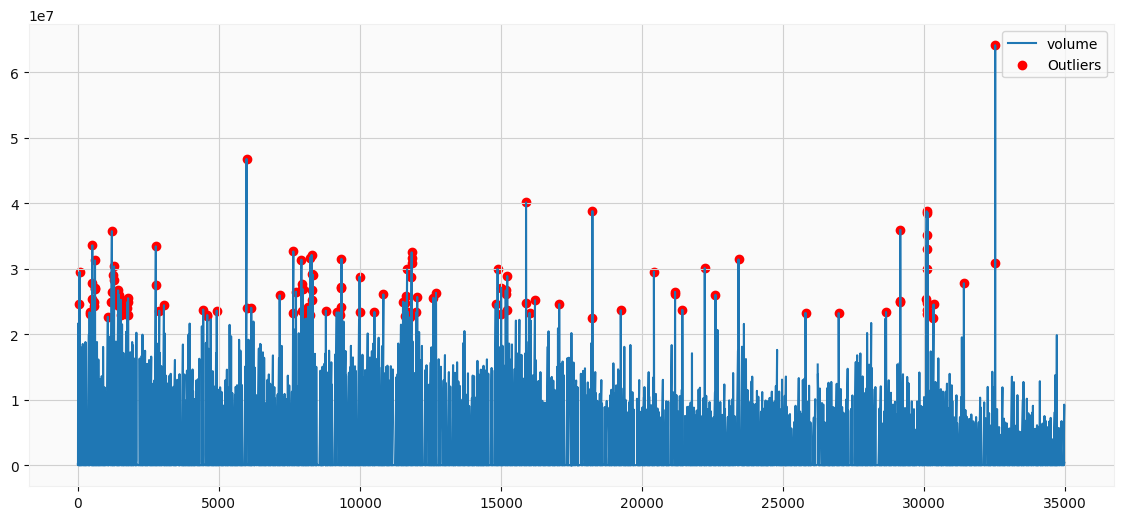

Buscando Outliers: MSFT...
... 159/34981 outliers (0.45 %)


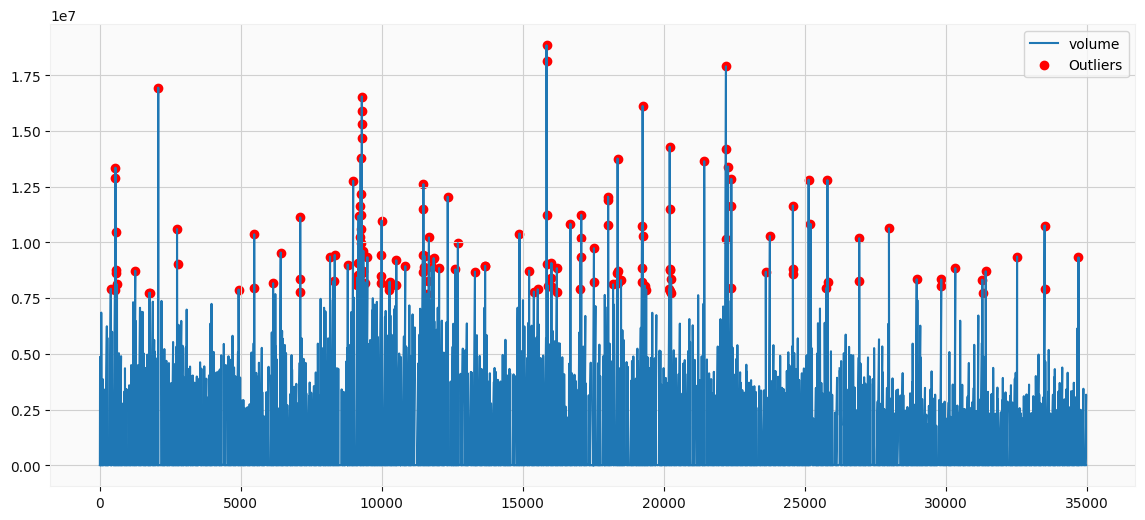

Buscando Outliers: NVDA...
... 106/34981 outliers (0.30 %)


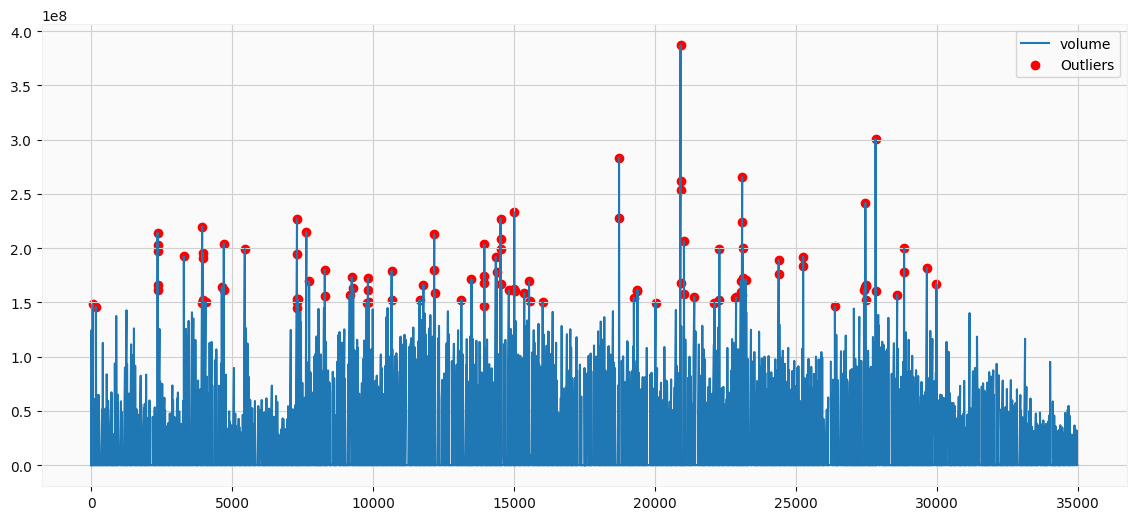

Buscando Outliers: IBM...
... 146/34981 outliers (0.42 %)


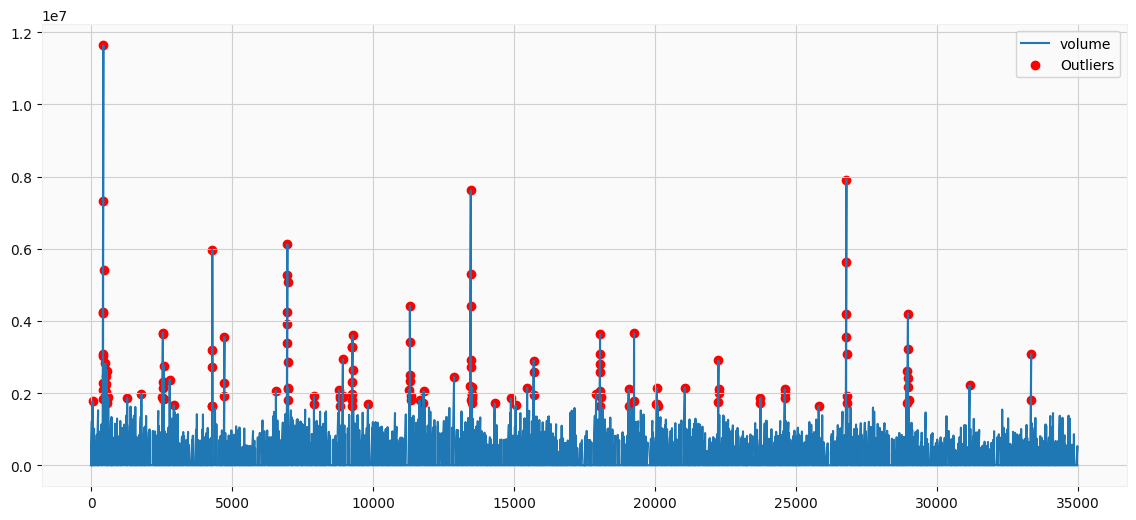

Buscando Outliers: GOOG...
... 155/34981 outliers (0.44 %)


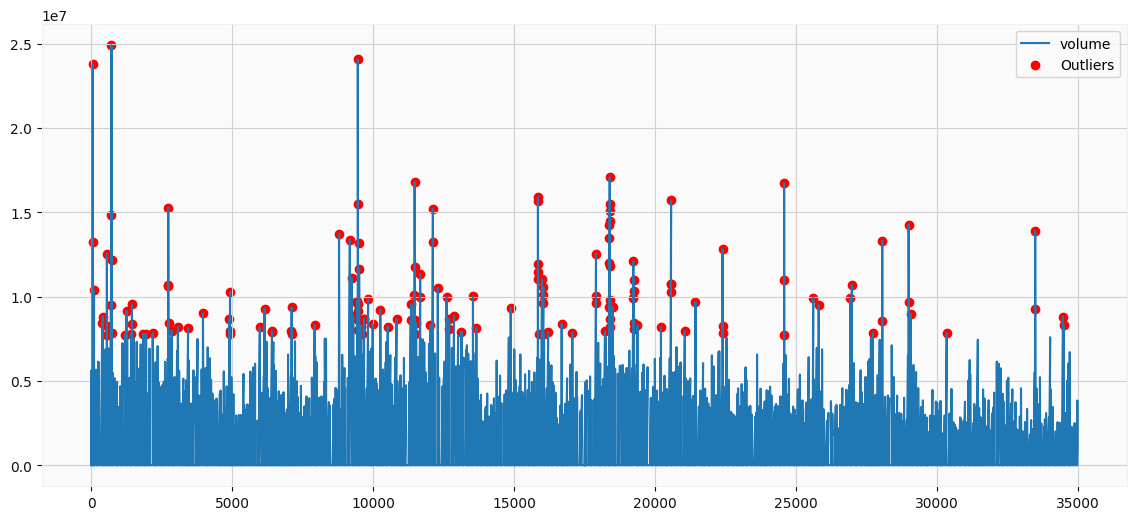

In [10]:
# search for volume outliers
# busca outliers
process_outliers = True
for TICKER in TICKERS:
    print(f"Buscando Outliers: {TICKER}...")
    count = 0
    input_path = OUTPUT_PATH + f"/{TICKER}1.csv"
    output_path = OUTPUT_PATH + f"/{TICKER}2.csv"
    df = pd.read_csv(input_path, parse_dates=[DATETIME_COL])
    
    # compute log return
    def detect_outliers_zscore(df, column, threshold=5):
        mean = df[column].mean()
        std = df[column].std()
        z = (df[column] - mean) / std
        return df[np.abs(z) > threshold]

    # Example:
    outliers_z = detect_outliers_zscore(df, "volume", threshold=5)

    # log
    print(f"... {len(outliers_z)}/{len(df)} outliers ({(len(outliers_z)/len(df))*100:.2f} %)")

    plt.figure(figsize=(14,6))
    plt.plot(df.index, df["volume"], label="volume")
    plt.scatter(outliers_z.index, outliers_z["volume"], color="red", label="Outliers")
    plt.legend()
    plt.show()

Creadon ETF...


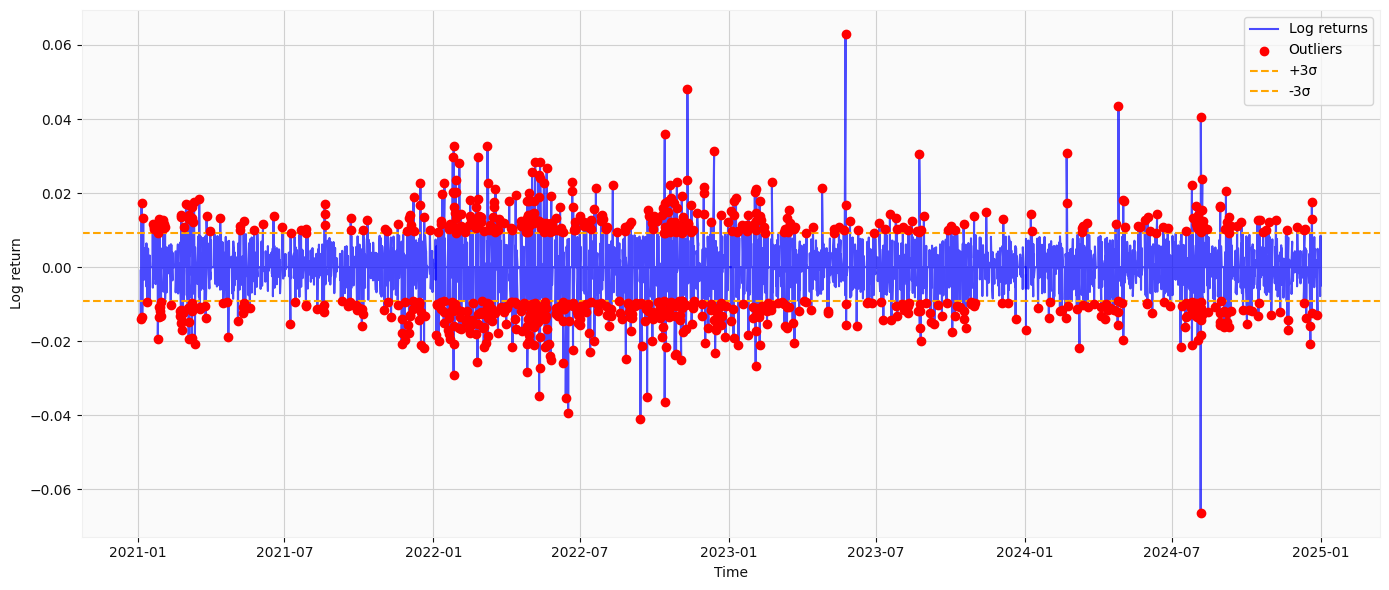

869/34980 outliers (2.48 %)


C:\Users\MarcDelosPoch\AppData\Local\Temp\ipykernel_20656\3028498127.py:180: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_etf.fillna(method='ffill', inplace=True)


,date_hour,date_day,date_month,close,volume,log_volume,ema10,ema50,ema200,ema_ratio,ema_spread,macd,macd_signal,macd_histogram,volatility_24h,obv,sofr,vix,log_return,target_log_return
datetime,,,,,,,,,,,,,,,,,,,,
2021-01-04 11:00:00,11,0,1,99.906747,26015,10.166467,99.906747,99.906747,99.906747,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.0010,26.97,-0.000933,0.000783
2021-01-04 12:00:00,12,0,1,99.985049,199527,12.203710,99.920984,99.909818,99.907526,1.000112,0.011166,0.006246,0.001249,0.004997,0.000000,1.995270e+05,0.0010,26.97,0.000783,-0.001044
2021-01-04 13:00:00,13,0,1,99.880734,255584,12.451310,99.913666,99.908677,99.907259,1.000050,0.004989,0.002748,0.001549,0.001199,0.000000,-5.605700e+04,0.0010,26.97,-0.001044,-0.002612
2021-01-04 14:00:00,14,0,1,99.620235,10999519,16.213362,99.860315,99.897366,99.904403,0.999629,-0.037051,-0.020805,-0.002922,-0.017884,0.000000,-1.105558e+07,0.0010,26.97,-0.002612,-0.001989
2021-01-04 15:00:00,15,0,1,99.422310,13845932,16.443502,99.780677,99.878736,99.899607,0.999018,-0.098059,-0.054811,-0.013300,-0.041511,0.000000,-2.490151e+07,0.0010,26.97,-0.001989,-0.009177
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-31 18:00:00,18,1,12,475.395843,1898940,14.456807,479.881709,483.276316,481.005555,0.992976,-3.394607,-1.561455,-1.040047,-0.521409,0.002829,1.874310e+09,0.0449,17.35,-0.005047,0.002644
2024-12-31 19:00:00,19,1,12,476.654662,1824399,14.416762,479.294973,483.016643,480.962262,0.992295,-3.721670,-1.731628,-1.178363,-0.553265,0.002913,1.876135e+09,0.0449,17.35,0.002644,-0.002787
2024-12-31 20:00:00,20,1,12,475.328246,4283773,15.270345,478.573750,482.715138,480.906202,0.991421,-4.141388,-1.951031,-1.332897,-0.618134,0.002539,1.871851e+09,0.0449,17.35,-0.002787,0.000548


In [11]:
print(f"Creadon ETF...")

# weights
with open(OUTPUT_PATH + "/etf_weights.json", "r", encoding="utf-8") as f:
    weights = json.load(f)

# load all csv
dfs = {}
for ticker in TICKERS:
    df = pd.read_csv(OUTPUT_PATH + f"/{ticker}2.csv", parse_dates=[DATETIME_COL])
    df = df.set_index(DATETIME_COL)
    dfs[ticker] = df
    
# compute log_return
df_etf = pd.read_csv(OUTPUT_PATH + f"/{TICKERS[0]}2.csv", parse_dates=[DATETIME_COL])
df_etf = df_etf.set_index(DATETIME_COL)
for ticker in dfs:
    df_etf[ticker] = dfs[ticker]["log_return"]
df_etf["log_return"] = sum(df_etf[ticker] * weight for ticker, weight in weights.items())

# detect log_return outliers
if True:
    z_thresh = 3
    mean = df_etf["log_return"].mean(skipna=True)
    std  = df_etf["log_return"].std(skipna=True)
    threshold = z_thresh * std
    df_etf["ret_outlier"] = (df_etf["log_return"].sub(mean).abs() > threshold )
    # mostramos los outliers de cada dataframe
    df_etf_to_plot = df_etf.copy()
    df_etf_to_plot.reset_index(inplace=True)
    plt.figure(figsize=(14,6))
    plt.plot(df_etf_to_plot["datetime_utc"], df_etf_to_plot["log_return"], label="Log returns", color="blue", alpha=0.7)
    plt.scatter(df_etf_to_plot.loc[df_etf_to_plot["ret_outlier"], "datetime_utc"], df_etf_to_plot.loc[df_etf_to_plot["ret_outlier"], "log_return"], color="red", label="Outliers", zorder=5)
    plt.axhline(mean + z_thresh*std , color="orange", linestyle="--", label=f"+{z_thresh}σ")
    plt.axhline(mean - z_thresh*std , color="orange", linestyle="--", label=f"-{z_thresh}σ")
    plt.xlabel("Time")
    plt.ylabel("Log return")
    plt.legend()
    plt.tight_layout()
    plt.show()
    print(f"{df_etf["ret_outlier"].sum()}/{len(df_etf)} outliers ({(df_etf["ret_outlier"].sum()/len(df_etf))*100:.2f} %)")
    # capamos los outliers
    df_etf["log_return"] = df_etf["log_return"].clip(mean - z_thresh * std, mean + z_thresh * std)

# compute close (ETF price (close) is reconstructed from weighted log returns)
df_etf["close"] = 100 * (df_etf["log_return"].cumsum().apply(lambda x: np.exp(x)))

# compute volume (ETF volume is computed using dollar-volume aggregation) buscar formula!!
dollar_vols = []
for ticker, w in weights.items():
    df = dfs[ticker]
    dv = df["close"] * df["volume"] * w
    dollar_vols.append(dv)
total_dollar_vol = sum(dollar_vols) # Sum across stocks → total weighted dollar-volume
df_etf["volume"] = (total_dollar_vol / df_etf["close"]).astype(int) # Convert to ETF volume (in ETF share equivalents)

# compute log_volume
df_etf['log_volume'] = np.log1p(df_etf['volume']) 
# Explicación: "Given the highly skewed distribution of trading volume, a logarithmic transformation (log_volume = log(1 + volume)) was applied to reduce the impact of extreme values and improve model stability. This transformation is especially useful for linear models and helped normalize the feature distribution for better learning."
# Explicación: usamos log1p 

# open, high, low (for graphics purposes)
df_etf["open"] = df_etf["close"].shift(1)
df_etf.loc[df_etf["open"].isna(), "open"] = df_etf["close"].iloc[0]
df_etf["high"] = np.maximum(df_etf["open"], df_etf["close"])
df_etf["low"]  = np.minimum(df_etf["open"], df_etf["close"])

# date 
df_etf["date_hour"]  = df.index.hour
df_etf["date_day"]  = df.index.dayofweek
df_etf["date_month"]  = df.index.month

# Trend: EMA(10) 
# explicación:The EMA10 was computed exclusively using real trading data, excluding forward-filled close prices during 
# weekends and non-trading hours. As a result, EMA10 is undefined (NaN) during periods without market activity. 
# This approach ensures that the moving average reflects actual price dynamics rather than artificially flat values. 
# For machine learning purposes, forward-filling was applied only to the EMA column to maintain continuity in the feature set.
# While these periods contain no price movement, forward-filling preserves the last valid trend estimate for modeling purposes. This treatment is acceptable in a predictive context but would not be used for real-time signal generation
df_etf_trading = df_etf[df_etf['volume'] > 0].copy()
df_etf_trading["ema10"] = df_etf_trading['close'].ewm(span=10, adjust=False).mean()
df_etf = df_etf.merge(df_etf_trading[['ema10']], how='left', left_index=True, right_index=True)
# explanation ema10 = short trend

# Trend: EMA(50) 
df_etf_trading = df_etf[df_etf['volume'] > 0].copy()
df_etf_trading["ema50"] = df_etf_trading['close'].ewm(span=50, adjust=False).mean()
df_etf = df_etf.merge(df_etf_trading[['ema50']], how='left', left_index=True, right_index=True)
# explanation ema10 = medium trend

# Trend: EMA(200) 
df_etf_trading = df_etf[df_etf['volume'] > 0].copy()
df_etf_trading["ema200"] = df_etf_trading['close'].ewm(span=200, adjust=False).mean()
df_etf = df_etf.merge(df_etf_trading[['ema200']], how='left', left_index=True, right_index=True)

# Trend: EMA Ratio EMA10 / EMA50
df_etf_trading = df_etf[df_etf['volume'] > 0].copy()
df_etf_trading["ema_ratio"] = df_etf_trading['ema10'] / df_etf_trading['ema50']
df_etf = df_etf.merge(df_etf_trading[['ema_ratio']], how='left', left_index=True, right_index=True)

# Trend: EMA Spreads EMA10 - EMA50
df_etf_trading = df_etf[df_etf['volume'] > 0].copy()
df_etf_trading["ema_spread"] = df_etf_trading['ema10'] - df_etf_trading['ema50']
df_etf = df_etf.merge(df_etf_trading[['ema_spread']], how='left', left_index=True, right_index=True)

# Trend MACD
df_etf_trading = df_etf[df_etf['volume'] > 0].copy()
df_etf_trading["ema12"] = df_etf_trading['close'].ewm(span=12, adjust=False).mean()
df_etf_trading["ema26"] = df_etf_trading['close'].ewm(span=26, adjust=False).mean()
df_etf_trading["ema9"] = df_etf_trading['close'].ewm(span=9, adjust=False).mean()
df_etf_trading['macd'] = df_etf_trading['ema12'] - df_etf_trading['ema26']
df_etf_trading['macd_signal'] = df_etf_trading['macd'].ewm(span=9, adjust=False).mean()
df_etf_trading['macd_histogram'] = df_etf_trading['macd'] - df_etf_trading['macd_signal']

df_etf['macd'] = df_etf_trading['macd']
df_etf['macd_signal'] = df_etf_trading['macd_signal']
df_etf['macd_histogram'] = df_etf_trading['macd_histogram'] # Momentum: MACD histogram
# explanation: "To capture short- and medium-term price dynamics, the 10-period EMA (EMA10) and 50-period EMA (EMA50) were selected. 
# EMA10 reflects short-term momentum, while EMA50 serves as a medium-term trend indicator, enabling the analysis of moving average crossovers.
# Additionally, the Moving Average Convergence Divergence (MACD) was computed using its standard parameters (12, 26, 9), which are widely 
# adopted in both academic research and practice. The MACD line represents the difference between the 12-period and 26-period EMAs, while 
# the signal line is a 9-period EMA of the MACD. The histogram, defined as the difference between the MACD and its signal line, captures 
# momentum shifts. These indicators were chosen due to their interpretability and established relevance in financial time series analysis."

# Volatility: volatility of log_returns
# - Econometrically standard: directly tied to realized variance; comparable to ARCH/GARCH literature and most forecasting papers.
# - Stationarity-friendly: log-returns are closer to stationary; ATR is in price units, so it scales with level and regimes.
# - Model-ready: easy to normalize, annualize, lag, and plug into LSTM/Transformers.
# - Data-parsimonious: works with what you already have (log_return), no High/Low needed.
# - Comparability: cross-asset and cross-time comparisons are straightforward.
volatility_window = 24  # 24 hourly bars ~1 day
df_etf['volatility_24h'] = df_etf['log_return'].rolling(volatility_window).std()
df_etf['volatility_24h'] = df_etf['volatility_24h'].fillna(0)

# Volume: OBV (Cumulative volume adjusted for the direction of price change.)
# - Detects whether money is “flowing in or out,” often used to confirm trends.
df_etf['obv'] = (np.sign(df_etf['close'].diff()) * df_etf['volume']).fillna(0).cumsum()

# Risk-adjusted: Rolling Sharpe (with SOFR)
# ???????

# funcmental SOFR
sofr_df = pd.read_csv(DOWNLOAD_PATH + "/SOFR.csv", parse_dates=["date"])
sofr_df["date"] = sofr_df["date"].dt.date
df_etf["date"] = df_etf.index.date
df_etf.reset_index(inplace=True)
df_etf = df_etf.merge(
    sofr_df,
    on="date",
    how="left"
)
df_etf["sofr"] = df_etf["sofr"] / 100 # from percentage to [0..1]
df_etf = df_etf.set_index(DATETIME_COL)

# fundamental VIX
vix_df = pd.read_csv(DOWNLOAD_PATH + "/VIX.csv", parse_dates=["date"])
vix_df["date"] = vix_df["date"].dt.date
df_etf.reset_index(inplace=True)
df_etf = df_etf.merge(
    vix_df,
    on="date",
    how="left"
)
df_etf = df_etf.set_index(DATETIME_COL)
# ALERT: we should post process it ???? YES !! or remove it

# fundamental Nasdaq-100 level
# ????? ...

# target log_return
# df_etf["target_log_return"] = np.log(df_etf["close"].shift(-1) / df_etf["close"])
df_etf["target_log_return"] = df_etf["log_return"].shift(-1)

# target close
df_etf["target_close"] = df_etf["close"].shift(-1)

# selecct columns
df_etf = df_etf[["date_hour","date_day","date_month","close","volume","log_volume","ema10","ema50","ema200","ema_ratio","ema_spread","macd","macd_signal","macd_histogram","volatility_24h","obv","sofr","vix","log_return","target_log_return"]]

# forward fill NaN (ema10, ema50, ...)
df_etf.fillna(method='ffill', inplace=True)

# save dataframe
df_etf.reset_index(inplace=True)
df_etf = df_etf.rename(columns={DATETIME_COL: "datetime"})
df_etf.to_csv(OUTPUT_PATH + "/_etf.csv", index=False)

# show dataframe
df_etf = df_etf.set_index("datetime")
df_etf


#print(df_etf[["target_log_return"]].mean())



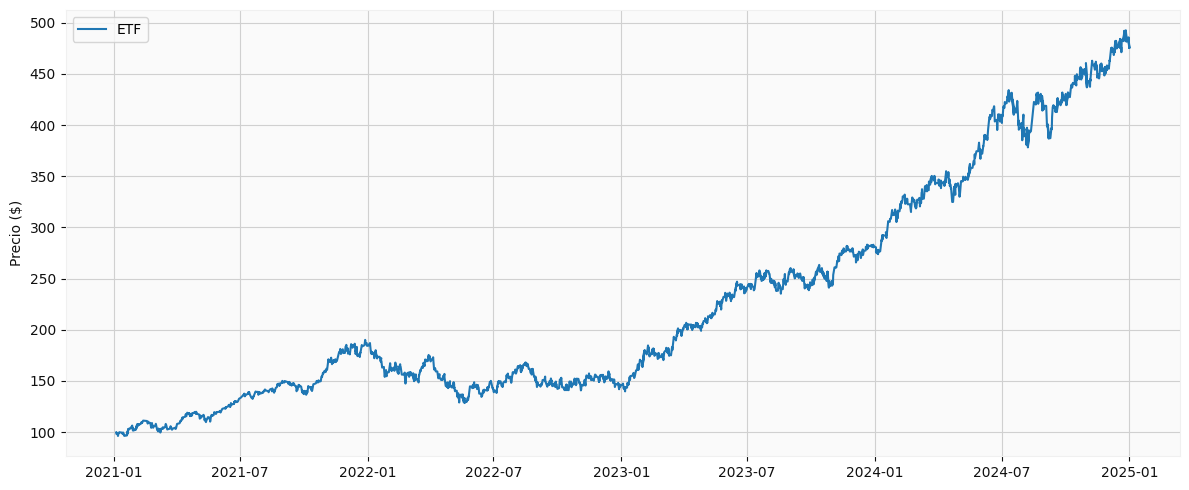

In [12]:
#plot
plt.figure(figsize=(12,5))
plt.plot(df_etf.index, df_etf["close"], label="ETF")
#plt.title("Precio del ETF")
#plt.xlabel("Time")
plt.ylabel("Precio ($)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
 